In [1]:
import pickle

# Definición de la instancia del grafo de Kanto para la simulación
f = frozenset

# Conjunto de vértices como frozenset
V = f({
    'Indigo Plateau',
    'Pallet Town',
    'Viridian City',
    'Pewter City',
    'Cinnabar Island',
    'Cerulean City',
    'Saffron City',
    'Celadon City',
    'Lavender Town',
    'Vermillion City',
    'Fuschia City',
    'Special Region'})

# Conjunto de aristas no dirigidas entre ciudades.
# Cada arista es un frozenset({u, v}) para que no importe el orden (u–v == v–u).
E = f({
    f({'Indigo Plateau', 'Viridian City'}),
    f({'Pallet Town', 'Viridian City'}),
    f({'Viridian City', 'Pewter City'}),
    f({'Pewter City', 'Cerulean City'}),
    f({'Cerulean City', 'Saffron City'}),
    f({'Saffron City', 'Celadon City'}),
    f({'Celadon City', 'Fuschia City'}),
    f({'Fuschia City', 'Special Region'}),
    f({'Fuschia City', 'Cinnabar Island'}),
    f({'Vermillion City', 'Special Region'}),
    f({'Cinnabar Island', 'Pallet Town'}),
    f({'Saffron City', 'Lavender Town'}),
    f({'Saffron City', 'Vermillion City'}),
    f({'Lavender Town', 'Cerulean City'}),
    f({'Lavender Town', 'Special Region'})
    })

# Tupla con el grafo en formato de conjuntos
G = (V, E)

# Usamos las listas, por comodidad
V = list(V) # lista de vertices
E = list(E) # lista de aristas ({u, v})


# Empaquetamos todo en 'data' y se guarda en un fichero binario con pickle
data = G, V, E
with open('instance.pickle', 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)

print('Kanto League map problema successfully pickled!')


Kanto League map problema successfully pickled!


In [2]:
import pickle
import itertools
import sys
import os
from joblib import Parallel, delayed, parallel_backend
import importlib.metadata

project_path = "/home/pablo/Documentos/TFG/codigo_base/simulacion_adiabatica"
if project_path not in sys.path:
    sys.path.append(project_path)

import numpy as np
from qutip import basis, tensor, sesolve, Options, QobjEvo, expect, qeye, sigmaz
# basis(dim, i): |i> en dimensión 'dim'
# tensor(...): producto tensorial de kets/operadores
# sesolve: ecuación de Schrödinger
# QobjEvo: envoltorio para Hamiltonianos dependientes del tiempo H(t)
# expect: valor esperado <ψ|O|ψ>
# qeye: identidad
# sigmaz: matriz de Pauli Z

from qm import Sx, Sz

from hamiltonians import HMIS_, HMVC_

from solvers import solveAll

from utils import osum, makePairs

from plotting import plotEnergy, plotFidelities, plotFidelitiesAcc, plotLegend

In [3]:
from collections import deque # Importamos la cola para usarla en BFS
import numpy as np

# Utilidades base

def measureEnergy(t, psi):
    """
    Calcula la energía esperada ⟨ψ(t)|H(t)|ψ(t)⟩ del estado `psi` en el instante `t`.

    Esta función evalúa el Hamiltoniano dependiente del tiempo `H_evo(t)`
    y calcula el valor esperado usando `expect` (de QuTiP).

    Params
    ----------
    t : float
        Instante de tiempo en el que se evalúa el Hamiltoniano de evolución H(t).

    psi : qutip.Qobj
        Estado cuántico (ket o densidad) en el cual se evalúa la energía esperada.

    Returns
    -------
    float
        Energía esperada ⟨psi|H(t)|psi⟩.
    """
    H_t = H_evo(t)
    return expect(H_t, psi)

def compute_fidelity_energy(args):
    """
    Calcula (fidelidad, energía) de una configuración clásica respecto a un estado objetivo.

    Para una configuración binaria (x_0, ..., x_{N-1}), construye el estado base computacional:
        |x_0 x_1 ... x_{N-1}>

    Luego:
      - Fidelidad = |⟨refket | ket⟩|^2, donde `ket` es el estado objetivo.
      - Energía    = ⟨refket | Hf | refket⟩, energía de esa base respecto a Hf (Hamiltoniano final).

    Params
    ----------
    args : tuple
        args = (configuration, N, Hf, ket)
        - configuration : tuple[int]
            Tupla de longitud N con bits 0/1.
        - N : int
            Número de qubits.
        - Hf : qutip.Qobj
            Hamiltoniano final (normalmente el problema Ising/QUBO convertido).
        - ket : qutip.Qobj
            Estado objetivo (por ejemplo el estado final simulado).

    Returns
    -------
    tuple[float, float]
        (fidelity, energy)
        - fidelity : float
            Probabilidad |⟨refket|ket⟩|^2
        - energy : float
            ⟨refket|Hf|refket⟩
    """
    configuration, N, Hf, ket = args
    
    # Construye el estado cuántico |x_0 x_1 ... x_N> mediante producto tensorial
    refket = tensor([basis(2, value) for value in configuration])
    
    # Probabilidad de encontrar el sistema en este estado (overlap al cuadrado)
    fidelity = np.abs(refket.overlap(ket))**2.
    energy = expect(Hf, refket)
    return fidelity, energy

def extractFidelities(N, Hf, ket, top):
    """
    Calcula fidelidades y energías de TODAS las configuraciones de N bits y devuelve el top por fidelidad.

    Recorre las 2^N configuraciones posibles de la base computacional y calcula para cada una:
      - fidelidad con el estado objetivo `ket`
      - energía con respecto a Hf

    Luego selecciona las `top` configuraciones con mayor fidelidad.

    Params
    ----------
    N : int
        Número de qubits (se exploran 2^N estados).

    Hf : qutip.Qobj
        Hamiltoniano final (problema).

    ket : qutip.Qobj
        Estado objetivo (por ejemplo, estado final de la simulación).

    top : int
        Número de configuraciones que se quieren devolver ordenadas por fidelidad.

    Returns
    -------
    tuple
        (top_configurations, top_fidelities, top_energies)
        - top_configurations : list[tuple[int]]
            Configuraciones (bits) más probables.
        - top_fidelities : np.ndarray
            Fidelidades correspondientes.
        - top_energies : np.ndarray
            Energías correspondientes (con Hf).
    """
    
    configurations = list(itertools.product([0, 1], repeat=N))

    # Calcula la fidelidad para cada uno de los 2^N estados posibles
    results = [compute_fidelity_energy((config, N, Hf, ket)) for config in configurations]

    fidelities = np.fromiter((f for f, _ in results), dtype=float, count=len(results))
    energies   = np.fromiter((e for _, e in results), dtype=float, count=len(results))

    if top >= len(fidelities):
        order = np.argsort(-fidelities) # Ordena todo si se piden más de los que hay
    else:
        # argpartition pone los 'top' mejores al principio sin ordenar todo el array
        best = np.argpartition(-fidelities, top-1)[:top]
        order = best[np.argsort(-fidelities[best])]

    top_configurations = [configurations[i] for i in order]
    top_fidelities     = fidelities[order]
    top_energies       = energies[order]
    return top_configurations, top_fidelities, top_energies

def measureEnergyFidelities(t, psi):
    """
    Función de medida para sesolve (e_ops)
    
    Params
    ----------
    t : float
        Tiempo actual de evolución.

    psi : qutip.Qobj
        Estado cuántico en el instante t.

    Returns
    -------
    list[float]
        Lista con energía, fidelidades individuales y suma.
    """
    
    H_t = H_evo(t)
    energy = float(expect(H_t, psi))
    # Compara el estado actual psi(t) contra las soluciones conocidas (sol_kets)
    chosen = sol_kets if MAX_REFS is None else sol_kets[:MAX_REFS]
    fids = [float(abs(psi.overlap(k))**2) for k in chosen]
    fsum = float(sum(fids))
    return [energy] + fids + [fsum]

def base_computacional(bitlist):
    """
    Construye el ket de QuTiP correspondiente a una configuración clásica de bits.

    Params
    ----------
    bitlist : list[int] | tuple[int]
        Lista/tupla de bits (0/1) de longitud N.
        
    Returns
    -------
    qutip.Qobj
        Estado |b0 b1 ... b_{N-1}> como producto tensorial de basis(2, b).
    """
    
    return tensor([basis(2, b) for b in bitlist])

# Utilidades para transformar de BQM/QUBO a Ising

def H_desde_Ising(N, h, J, offset=0.0):
    """
    Construye el Hamiltoniano de Ising en base Z usando operadores de QuTiP.

    Forma:
        H = offset * I + Σ_i h_i Z_i + Σ_{i<j} J_ij Z_i Z_j

    Params
    ----------
    N : int
        Número de qubits.

    h : dict[int, float]
        Campos locales. Clave i, valor h_i.

    J : dict[tuple[int,int], float]
        Acoplamientos. Clave (i,j), valor J_ij (se asume i<j o se gestiona externamente).

    offset : float, opcional
        Término constante.

    Returns
    -------
    qutip.Qobj
        Hamiltoniano como operador sobre el espacio de Hilbert de N qubits.
    """
    H = 0
    if offset:
        H = H + offset * tensor([qeye(2) for _ in range(N)])
    for i, hi in h.items():
        H = H + hi * Sz(N, i) # Sz es la matriz de Pauli Z en el sitio i
    for (i, j), Jij in J.items():
        H = H + Jij * Sz(N, i) * Sz(N, j) # Interacción de dos cuerpos
    return H

def qubo_a_Ising(linear, quadratic, offset=0.0):
    """
    Convierte un QUBO (x∈{0,1}) a parámetros de Ising (s∈{+1,-1}).

    Usa la sustitución estándar:
        x_i = (1 - s_i) / 2
    donde s_i corresponde a un espín Ising (equivalente a Z_i con autovalores ±1).

    Params
    ----------
    linear : dict[int, float]
        Coeficientes lineales del QUBO.

    quadratic : dict[tuple[int,int], float]
        Coeficientes cuadráticos del QUBO.

    offset : float, opcional
        Constante del QUBO.

    Returns
    -------
    tuple
        (h, J, const)
        - h : dict[int, float]
        - J : dict[tuple[int,int], float]
        - const : float
    """
    # x_i = (1 - Z_i) / 2. Al sustituir esto en la fórmula QUBO, salen los términos h y J.
    h, J = {}, {}
    const = float(offset)
    for i, ai in linear.items():
        h[i] = h.get(i, 0.0) - 0.5 * ai
        const += 0.5 * ai
    for (i, j), bij in quadratic.items():
        if j < i: i, j = j, i
        J[(i, j)] = J.get((i, j), 0.0) + 0.25 * bij
        h[i] = h.get(i, 0.0) - 0.25 * bij
        h[j] = h.get(j, 0.0) - 0.25 * bij
        const += 0.25 * bij
    return h, J, const

def bqm_add_linear(linear, i, c):
    """
    Añade/Acumula un término lineal al QUBO.

    Modifica el diccionario `linear` in-place sumando:
        linear[i] += c

    Params
    ----------
    linear : dict[int, float]
        Diccionario de términos lineales del QUBO.

    i : int
        Índice de variable binaria.

    c : float
        Coeficiente a sumar.
    """
    linear[i] = linear.get(i, 0.0) + float(c)

def bqm_add_quad(quadratic, i, j, c):
    """
    Añade/Acumula un término cuadrático al QUBO (interacción entre variables i y j).

    Modifica `quadratic` in-place sumando:
        quadratic[(min(i,j), max(i,j))] += c

    Params
    ----------
    quadratic : dict[tuple[int,int], float]
        Diccionario de términos cuadráticos.

    i, j : int
        Índices de variables binarias (deben ser distintos).

    c : float
        Coeficiente a sumar.
    """
    if i == j:
        raise ValueError("No pongas términos (i,i) en quadratic; intégralos en linear si hace falta.")
    i, j = (i, j) if i < j else (j, i)
    quadratic[(i, j)] = quadratic.get((i, j), 0.0) + float(c)

def bqm_add_offset(current_offset, c):
    """
    Aumenta el término constante (offset) del QUBO.

    Params
    ----------
    current_offset : float
        Offset actual.

    c : float
        Incremento.

    Returns
    -------
    float
        Nuevo offset = current_offset + c
    """
    return current_offset + float(c)

def exactamente_uno(linear, quadratic, offset, vars_set, P):
    """
    Impone la restricción one-hot: EXACTAMENTE 1 variable activa en `vars_set`.

    Añade la penalización:
        P * (1 - Σ x_k)^2

    Expansión (x binaria, x^2=x):
      - offset += P
      - lineal  += -P * x_i
      - cuadrático += 2P * x_i x_j  (i<j)

    Params
    ----------
    linear, quadratic, offset :
        Estructura del QUBO a modificar.
    vars_set : list[int]
        Conjunto/lista de índices de variables.
    P : float
        Penalización (debe ser suficientemente grande para dominar a la parte de coste).

    Return
    -------
    float
        Nuevo offset tras aplicar la penalización.
    """
    # Se expande el binomio (1 - sum x)^2 = 1 - 2*sum(x) + sum(x)^2
    # Como x^2 = x (para binarios), se simplifica algebraicamente.
    offset = bqm_add_offset(offset, P)
    for i in vars_set:
        bqm_add_linear(linear, i, -P)
    for indx_a in range(len(vars_set)):
        for indx_b in range(indx_a+1, len(vars_set)):
            a, b = vars_set[indx_a], vars_set[indx_b]
            bqm_add_quad(quadratic, a, b, 2.0*P) # Penaliza tener dos qubits activos simultáneamente
    return offset

def exactamente_k(linear, quadratic, offset, vars_set, K, P):
    """
    Impone EXACTAMENTE K variables activas en `vars_set`.

    Penalización:
        P * (Σ x_i - K)^2

    Expansión (x binaria, x^2=x):
      - offset      += P*K^2
      - lineales    += P*(1 - 2K) * x_i
      - cuadráticos += 2P * x_i x_j

    Params
    ----------
    linear, quadratic, offset :
        Estructura del QUBO a modificar.
    vars_set : list[int]
        Conjunto/lista de índices.
    K : int
        Número exacto de activos.
    P : float
        Penalización.

    Returns
    -------
    float
        Nuevo offset tras aplicar la penalización.
    """
    
    offset = bqm_add_offset(offset, P * (K ** 2))
    for i in vars_set:
        bqm_add_linear(linear, i, P * (1.0 - 2.0 * K))
    for a in range(len(vars_set)):
        for b in range(a + 1, len(vars_set)):
            bqm_add_quad(quadratic, vars_set[a], vars_set[b], 2.0 * P)
    return offset

# Mapeo x_{i,t} -> índice único de variable
def indx(i, t, n_slots):
    """
    Mapea una variable 2D x_{i,t} (ciudad i, slot t) a un índice 1D único.
    Se usa para aplanar una matriz (n_ciudades x n_slots) en un vector de qubits.

    Params
    ----------
    i : int
        Índice de ciudad.

    t : int
        Índice de slot/tiempo.

    n_slots : int
        Número total de slots.

    Returns
    -------
    int
        Índice único: i*n_slots + t
    """
    return i * n_slots + t  # Aplana matriz (ciudades x tiempo) a vector 1D

# BFS
def dist_bfs(stqubo):
    """
    Calcula distancias mínimas desde un nodo origen usando BFS (en número de aristas).

    Params
    ----------
    stqubo : hashable
        Nodo origen.

    Returns
    -------
    dict
        Diccionario dist[u] = distancia mínima desde stqubo a u.
        Si un nodo no es alcanzable, su distancia queda como np.inf.
    """
    dist = {u: np.inf for u in V}
    dist[stqubo] = 0
    q = deque([stqubo])
    while q:
        u = q.popleft()
        for w in adj[u]:
            if dist[w] == np.inf:
                dist[w] = dist[u] + 1
                q.append(w)
    return dist


def secuencia_mvrp(bits, n_ciudades, n_slots):
    """
    Decodifica un bitstring a una secuencia de ciudades por slot.

    Interpreta `bits` como una matriz X de tamaño (n_ciudades, n_slots) donde:
        X[i,t] = 1  ⇔  en el slot t se elige la ciudad i

    Para cada slot t, devuelve el índice i con máximo valor (argmax).

    Params
    ----------
    bits : array-like
        Vector binario de longitud n_ciudades*n_slots.

    n_ciudades : int
        Número de ciudades.

    n_slots : int
        Número de slots.

    Returns
    -------
    list[int]
        Lista de longitud n_slots con el índice de ciudad elegido en cada slot.
    """
    # Reconstruye la matriz (ciudades x tiempo) desde el vector de bits plano
    X = np.asarray(bits, dtype=int).reshape(n_ciudades, n_slots)  # filas=i, cols=t
    # Encuentra qué ciudad está activa (tiene un 1) en cada columna de tiempo
    return X.argmax(axis=0).tolist()

def secuencia_segmentos(seq, origen_indx=0):
    """
    Segmenta una secuencia circular usando un depósito único como separador.

    Asume que:
      - `seq` contiene apariciones del depósito `origen_indx`.
      - Cada vez que aparece el depósito, se cierra una ruta y comienza otra.

    La función rota la secuencia hasta la primera aparición del depósito y recorre el anillo,
    devolviendo las rutas SIN incluir el depósito.

    Params
    ----------
    seq : list[int]
        Secuencia de índices de ciudad por slot.

    origen_indx : int, opcional
        Índice del depósito.

    Returns
    -------
    list[list[int]]
        Lista de rutas (cada ruta es lista de clientes sin depósito).
        Si el depósito no aparece, devuelve [].
    """
    if origen_indx not in seq:
        return []
    stqubo = seq.index(origen_indx)
    # recorre desde el primer depósito y cierra en el siguiente
    ring = seq[stqubo+1:] + seq[:stqubo+1]
    rutas, actual = [], []
    for c in ring:
        if c == origen_indx:
            rutas.append(actual)
            actual = []
        else:
            actual.append(c)
    return rutas

def mvrp_solucion_lenguaje_natural(bits, ciudades, n_slots, costes, origenes_indx, origen_indx=0):
    """
    Convierte una solución (bitstring) en texto legible: rutas por vehículo y coste total.

    Flujo:
      1) decodifica el bitstring a una secuencia global (slot->ciudad)
      2) segmenta esa secuencia en rutas separadas por depósitos (multi-depósito)
      3) ignora rutas sin clientes (tiempos de espera)
      4) calcula coste real sumando aristas de cada ruta
      5) devuelve un texto con una línea por vehículo

    Params
    ----------
    bits : array-like
        Bitstring solución.

    ciudades : list[str]
        Nombres de ciudades (depósitos + destinos).

    n_slots : int
        Número de slots del encoding.

    costes : np.ndarray
        Matriz de costes entre ciudades.

    origenes_indx : set/list[int]
        Índices de depósitos posibles.

    origen_indx : int, opcional
        Depósito por defecto (no imprescindible en esta implementación; se mantiene por compatibilidad).

    Returns
    -------
    str
        Texto en lenguaje natural describiendo rutas y coste total.
    """
    n_ciudades = len(ciudades)
    
    # 1. Decodificar bits a secuencia de índices de ciudades
    seq = secuencia_mvrp(bits, n_ciudades, n_slots)
    
    # 2. Partir la secuencia en rutas individuales basadas en los depósitos
    # Esto separa la lista única de tiempos en rutas lógicas por vehículo
    rutas = secuencia_segmentos_multi(seq, origenes_indx)
    
    lineas = []
    total_cost = 0.0

    contador_vehiculo = 1
    
    for r, (d_ini, clientes, d_fin) in enumerate(rutas, 1):
        # Reconstruir el camino de índices: Inicio -> Clientes -> Fin (si existe)

        # Filtro anti-rutas fantasma (si no hay clientes, es tiempo de espera)
        if not clientes:
            continue
        
        indices_camino = [d_ini] + clientes
        if d_fin is not None:
            indices_camino.append(d_fin)
            info_fin = f", fin: {ciudades[d_fin]}"
        else:
            info_fin = ""  # Ruta abierta

        # Calcular coste específico de esta ruta sumando aristas
        coste_ruta = 0.0
        for k in range(len(indices_camino) - 1):
            u = indices_camino[k]
            v = indices_camino[k+1]
            coste_ruta += costes[u, v]
        
        total_cost += coste_ruta
        
        # Formatear texto
        nombres_camino = [ciudades[i] for i in indices_camino]
        str_camino = " → ".join(nombres_camino)
        
        lineas.append(f"  Vehículo {contador_vehiculo} (inicio: {ciudades[d_ini]}{info_fin}): {str_camino}")
        contador_vehiculo += 1

    # Insertamos el coste total al principio
    lineas.insert(0, f"Solución propuesta (coste total = {total_cost:.0f}):")
    
    return "\n".join(lineas)


# Adaptación para el plotting
def truncar_5_canales(f_dyn):
    """
    Adapta un tensor de medidas dinámicas (canales, runs, muestras) a un formato fijo de 5 canales.
    
      - C: canales (energía, fidelidades..., suma fidelidades)
      - R: número de runs
      - M: número de puntos temporales

    Esta función crea un tensor de salida `out` con forma (5, R, M):
      - out[0] = energía
      - out[1..3] = hasta 3 fidelidades (si existen)
      - out[4] = suma de fidelidades (último canal original)

    Params
    ----------
    f_dyn : np.ndarray
        Array de shape (C, R, M).

    Returns
    -------
    np.ndarray
        Array de shape (5, R, M).
    """

    # Esta función se usa solo para visualización, normalizando los datos para una gráfica fija
    C, R, M = f_dyn.shape
    if C < 2:
        raise ValueError(f"Se esperaban al menos energía y suma; C={C}")
    out = np.zeros((5, R, M))
    out[0, :, :] = f_dyn[0, :, :]          # energía
    # nº de fidelidades disponibles = C-2 (quitando energía y suma)
    num_fids = max(0, C - 2)
    take = min(3, num_fids)
    if take > 0:
        out[1:1+take, :, :] = f_dyn[1:1+take, :, :]
    out[4, :, :] = f_dyn[C-1, :, :]        # suma (último canal)
    return out

def mvrp_qubo(origenes, destinos, K, dists, P_pos, P_uno, P_deposito):
    """
    Construye el QUBO para un MVRP (multi-depósito, multi-vehículo) codificado por slots.

    Encoding:
      - Variables binarias x_{i,t} ∈ {0,1} representan “en el slot t estamos en la ciudad i”.
      - El espacio de variables es una matriz (n_ciudades x n_slots) aplanada con indx(i,t,n_slots).
      - La decodificación posterior interpreta la secuencia slot->ciudad y segmenta por depósitos.

    Restricciones implementadas (esta variante "multi-depósito en inicio"):
      1) Función objetivo: minimizar distancia total entre slots consecutivos.
      2) One-hot por slot: en cada t exactamente una ciudad activa.
      3) Cada destino aparece exactamente una vez en todos los slots.
      4) Condición de frontera inicial: en t=0 debe estar en UNO de los depósitos.
      5) Penalización de “transiciones depósito->depósito” (gestión de espera/saltos entre depósitos).
      6) Condición de frontera final: en el último slot debe estar en ALGÚN depósito.
      7) Penalización de repetición: no permanecer en la misma ciudad en slots consecutivos.

    Params
    ----------
    origenes : list[str] | str
        Lista de depósitos. Si se pasa un str, se convierte a lista de un elemento.

    destinos : list[str]
        Lista de ciudades destino (clientes).

    K : int
        Número de vehículos (en este encoding se traduce a slots extra de depósito).
        Nota: el sentido exacto de K depende de tu segmentación posterior.

    dists : dict[str, dict[str, float]]
        Distancias completas entre ciudades, accesibles como dists[ciudad_i][ciudad_j].

    P_pos : float
        Penalización para la restricción one-hot por slot.

    P_uno : float
        Penalización para “cada destino exactamente una vez”.

    P_deposito : float
        Penalización para condiciones/gestión de depósitos (inicio/fin/transiciones).

    Returns
    -------
    dict
        Diccionario con:
          - linear, quadratic, offset : QUBO en forma de diccionarios
          - N : número total de variables (qubits)
          - K : K usado
          - ciudades : lista completa (depósitos + destinos)
          - n_slots : número de slots del encoding
          - origenes_indx : lista de índices de depósitos dentro de `ciudades`
          - costes : matriz (n_ciudades x n_ciudades) con distancias
          - n_destinos : número de destinos
          - varmap : mapa idx_qubit -> (i, t)
    """

    if isinstance(origenes, str):
        origenes_aux = [origenes]
    else:
        origenes_aux = list(origenes)
    
    ciudades = origenes + destinos
    n_origenes = len(origenes_aux)
    n_ciudades = len(ciudades)
    n_destinos = len(destinos)
    # Slots necesarios: 1 por destino + 1 por inicio de vehículo + 1 cierre final
    n_slots = n_destinos + K + 1

    qubo_lineal, qubo_quad, offset_bqm = {}, {}, 0.0

    # Construcción de la matriz de costes (grafo completo con distancias)
    costes = np.zeros((n_ciudades, n_ciudades), dtype=float)
    for i, ci in enumerate(ciudades):
        for j, cj in enumerate(ciudades):
            costes[i, j] = float(dists[ci][cj])

    # Check de seguridad: La penalización P debe ser mayor que cualquier beneficio por distancia
    max_coste_mapa = np.max(costes)
    if P_pos < max_coste_mapa:
        print(f"AVISO: Aumentando P_pos de {P_pos} a {max_coste_mapa * 2} para evitar errores lógicos.")
        P_pos = max_coste_mapa * 2
        P_uno = P_pos + 10
        P_deposito = P_pos

    # 1. FUNCIÓN OBJETIVO: Minimizar distancia recorrida
    # Suma coste[i,j] si en t estamos en i y en t+1 estamos en j
    for t in range(n_slots - 1):
        t_next = t + 1
        for i in range(n_ciudades):
            for j in range(n_ciudades):
                coste = costes[i, j]
                if coste != 0.0:
                    bqm_add_quad(qubo_quad, indx(i, t, n_slots), indx(j, t_next, n_slots), coste)

    # 2. RESTRICCIÓN: En cada instante t, el vehículo debe estar en EXACTAMENTE UNA ciudad
    for t in range(n_slots):
        S = [indx(i, t, n_slots) for i in range(n_ciudades)]
        offset_bqm = exactamente_uno(qubo_lineal, qubo_quad, offset_bqm, S, P_pos)

    # 3. RESTRICCIÓN: Cada ciudad destino debe ser visitada EXACTAMENTE UNA vez en total
    # (Los depósitos se pueden visitar múltiples veces, por eso range empieza en n_origenes)
    for i in range(n_origenes, n_ciudades):
        S = [indx(i, t, n_slots) for t in range(n_slots)]
        offset_bqm = exactamente_k(qubo_lineal, qubo_quad, offset_bqm, S, 1, P_uno)

    # 4. CONDICIÓN DE FRONTERA: En t=0, debe estar en uno de los depósitos
    S0 = [indx(d, 0, n_slots) for d in range(n_origenes)]
    offset_bqm = exactamente_uno(qubo_lineal, qubo_quad, offset_bqm, S0, P_deposito)

    # 5. CONTINUIDAD DE DEPÓSITO: Si está en un depósito en t, puede quedarse o ir a otro depósito (gestión de espera)
    # Se penaliza ligeramente el cambio entre depósitos para evitar saltos innecesarios si no es para ruta
    for t in range(n_slots - 1):
        for d1 in range(n_origenes):
            for d2 in range(n_origenes):
                bqm_add_quad(qubo_quad, indx(d1, t, n_slots), indx(d2, t + 1, n_slots), P_deposito * 0.5)

    # 6. CONDICIÓN DE FRONTERA FINAL: En el último slot, debe terminar en un depósito
    SL = [indx(d, n_slots - 1, n_slots) for d in range(n_origenes)]
    offset_bqm = exactamente_uno(qubo_lineal, qubo_quad, offset_bqm, SL, P_deposito)

    # 7. CONTINUIDAD DE CIUDAD: no debe quedarse en una misma ciudad, esto se penaliza fuertemente
    P_rep = P_pos  # o 2*max_coste_mapa
    for t in range(n_slots - 1):
        for i in range(n_ciudades):
            bqm_add_quad(qubo_quad, indx(i, t, n_slots), indx(i, t+1, n_slots), P_rep)


    N_qubits = n_ciudades * n_slots
    varmap = {indx(i, t, n_slots): (i, t) for i in range(n_ciudades) for t in range(n_slots)}

    return {
        "linear": qubo_lineal,
        "quadratic": qubo_quad,
        "offset": float(offset_bqm),
        "N": int(N_qubits),
        "K": int(K),
        "ciudades": ciudades,
        "n_slots": int(n_slots),
        "origenes_indx": list(range(n_origenes)),
        "costes": costes,
        "n_destinos": n_destinos,
        "varmap": varmap
    }

def energia_qubo(bits, linear, quadratic, offset=0.0):
    """
    Evalúa la energía de un QUBO para un bitstring dado.

    E(x) = offset + Σ_i linear[i]*x_i + Σ_(i,j) quadratic[(i,j)]*x_i*x_j

    Params
    ----------
    bits : array-like
        Vector binario 0/1 de longitud N.

    linear : dict[int, float]
        Coeficientes lineales.

    quadratic : dict[tuple[int,int], float]
        Coeficientes cuadráticos (normalmente con i<j).

    offset : float, opcional
        Término constante.

    Returns
    -------
    float
        Energía QUBO.
    """
    
    e = float(offset)

    for i, a in linear.items():
        e += a * bits[i]
    for (i, j), c in quadratic.items():
        e += c * bits[i] * bits[j]
    return e

def secuencia_segmentos_multi(seq, depot_indices):
    """
    Segmenta una secuencia lineal en rutas separadas por depósitos (multi-depósito), sin cierre circular.

    Reglas:
      - Cada vez que aparece un depósito (índice en depot_indices) se considera inicio de ruta.
      - Si aparece otro depósito, se cierra la ruta actual y se abre una nueva.
      - La última ruta se cierra al final de la secuencia; su depósito final puede ser None si no aparece otro depósito al final.

    Params
    ----------
    seq : list[int]
        Secuencia de índices ciudad por slot.

    depot_indices : set[int] | list[int]
        Conjunto/lista de índices considerados depósitos.

    Returns
    -------
    list[tuple]
        Lista de tuplas:
          (dep_inicio, [clientes], dep_fin_o_None)
    """
    rutas, actual = [], []
    origen = None
    for s in seq:
        if s in depot_indices:
            if origen is None:
                origen = s # Primer depósito encontrado, empieza la primera ruta
            else:
                # Encontrado otro depósito: cerramos la ruta actual y empezamos una nueva
                rutas.append((origen, actual, s))
                origen, actual = s, []
        else:
            if origen is not None:
                actual.append(s) # Añadir cliente a la ruta actual

    if origen is not None:
        rutas.append((origen, actual, None)) # Añadir la última ruta (puede quedar abierta)
    return rutas

In [4]:
# "MIS" -> Maximum Independent Set
# "MVC" -> Minimum Vertex Cover
# "MVRP" -> Multi Vehicular Routing problema
problema = "MVRP"

MAX_REFS = None
NUM_VEHICULOS = 1

In [5]:
# Carga de instancia
with open('instance.pickle', 'rb') as f:
    data = pickle.load(f)

print('Kanto League map problema successfully unpickled!')
G, V, E = data

# A pquboir del grafo, construimos la lista de pares (i,j) para términos de Ising
pares = makePairs(V, E)


# Número de qubits del problema MIS/MVC (uno por vértice). MVRP lo cambiará más tarde.
N = len(V)

# Parámteros de la evolución adiabática
tmax = 100.     # tiempo adimensional en unidades de π
T = tmax*np.pi  # tiempo físico total
res = 1200       # número de puntos de tiempo

# Hamiltoniano inicial Hi = suma de Sx en cada qubit
# Para MVRP se cambia más tarde
Hi = osum([Sx(N, i) for i in range(N)])

# Selección del problema
if problema == "MIS":
    # MIS codificado como Ising en Z
    Hf = HMIS_(N, pares)

elif problema == "MVC":
    # MVC codificado como Ising en Z
    Hf = HMVC_(N, pares)

elif problema == "MVRP":

    P = 50.0
    qubo_lineal = {}
    qubo_quad = {}
    offset_bqm = 0.0

    # Número de vehículos (define NUM_VEHICULOS antes del selector)
    K = NUM_VEHICULOS if 'NUM_VEHICULOS' in globals() else 2
    if K < 1:
        raise ValueError("MVRP: NUM_VEHICULOS debe ser >= 1.")

    # --- Grafo y distancias ---
    adj = {v: set() for v in V}
    for e in E:
        a, b = tuple(e)
        adj[a].add(b); adj[b].add(a)

    dists = {v: dist_bfs(v) for v in V}

    origen = ["Pallet Town", "Celadon City", "Fuschia City"]
    destinos = ["Vermillion City"] 

    qubo = mvrp_qubo(origen, destinos, K, dists, P_pos=P, P_uno=P + 10, P_deposito=P)
    
    # QUBO -> Ising -> Hf
    N_qubits = qubo["N"]
    n_slots  = qubo["n_slots"]
    n_destinos  = qubo["n_destinos"]
    h_ising, J_ising, const_ising = qubo_a_Ising(qubo["linear"], qubo["quadratic"], qubo["offset"])
    Hf = H_desde_Ising(N_qubits, h_ising, J_ising, offset=const_ising)

    # Actualizar N y Hi (nuevo tamaño)
    N = N_qubits
    Hi = osum([Sx(N, i) for i in range(N)])

    print(f"MVRP: depósito = {origen}")
    print(f"MVRP: destinos = {destinos}  (n_destinos={n_destinos})")
    print(f"MVRP: vehículos K = {K}, slots = {n_slots}, N_qubits = {N_qubits}")

else:
    raise ValueError(f"Tipo de problema desconocido: {problema}")

H = [[Hi, (lambda t, args: 1. - t/T)], [Hf, (lambda t, args: t/T)]] # Hamiltoniano dependiente del tiempo
H_evo = QobjEvo(H) # evaluación de H(t) en cualquier t

# estado inicial
minus = (basis(2, 0) - basis(2, 1)).unit()
psi0 = tensor([minus for _ in range(N)])

# Dato temporal para la integración y opciones del solver
times = np.linspace(0., T, res)

# Se guarda el estado final en result.final_state
opts = {
    "store_final_state": True,
    "nsteps": 50000,        # Aumentamos el límite de pasos internos
}

# Se integra la ecuación de Schrödinger con e_ops=measureEnergy para registrar ⟨H(t)⟩
result = sesolve(H, psi0, times, e_ops=measureEnergy, options=opts)

# estado final de la evolución adiabática
psif = result.final_state

# energía esperada ⟨H(t)⟩
measurements = result.expect[0]

# Se guarda el análisis para el ploteo
np.save('energies.npy', measurements)

# Dependiendo del problema se generan unos sol_kets para analizar las fidelidades
if problema == "MIS":
    # Se obtienen soluciones MIS clásicas y se construyen los kets correspondientes
    lst, _ = solveAll([], 0, 9999, V, G)
    sol_kets_tot = []
    for sol in lst:
        # 1 = vértice no seleccionado, 0 = vértice seleccionado
        sll = [1 for _ in range(N)]
        for loc in sol:
            indx = V.index(loc)
            sll[indx] = 0
        sol_kets_tot.append(tensor([basis(2, v) for v in sll]))

    # SE ordena por fidelidad con psif
    sol_kets_sorted = sorted(sol_kets_tot,
                             key=lambda k: float(abs(psif.overlap(k))**2),
                             reverse=True)

    # Se seleccionan todas o recortamos según MAX_REFS
    if MAX_REFS is None:
        sol_kets = sol_kets_sorted
    else:
        sol_kets = sol_kets_sorted[:MAX_REFS]

elif problema == "MVC":

    # Limitación de tamaño para evitar errores durante las pruebas
    if N > 16:
        raise RuntimeError(f"MVC: N={N}, demasiado grande para escanear 2^N estados.")

    ener_diag, kets_diag = [], []
    for x in range(1 << N): # Se recorren todos los bitstrings de longitud N
        bits = [(x >> i) & 1 for i in range(N)]
        ket = base_computacional(bits)
        ener_diag.append(expect(Hf, ket)) # Como Hf está en Z, esto es el autovalor de |b>
        kets_diag.append(ket)

    ener_diag = np.array(ener_diag)
    E_min = ener_diag.min()
    min_indxs = np.where(np.isclose(ener_diag, E_min))[0] # índices de los estados fundamentales

    # Ordenar por fidelidad con psif y recortar según MAX_REFS
    min_sorted = sorted(
    min_indxs,
    key=lambda indx: float(abs(psif.overlap(kets_diag[indx]))**2),
    reverse=True)
    if MAX_REFS is None:
        sol_kets = [kets_diag[indx] for indx in min_sorted]
    else:
        sol_kets = [kets_diag[indx] for indx in min_sorted[:MAX_REFS]]

elif problema == "MVRP":
    
    if N > 16:
        raise RuntimeError(f"MVRP: N={N}, demasiado grande para escanear 2^N estados.")
    ener_diag, kets_diag , bits_diag = [], [], []
    for x in range(1 << N):
        bits = [(x >> i) & 1 for i in range(N)]
        bits_diag.append(bits)
        ket = base_computacional(bits)
        ener_diag.append(expect(Hf, ket))
        kets_diag.append(ket)

    ener_diag = np.array(ener_diag)
    E_min = ener_diag.min()
    min_indxs = np.where(np.isclose(ener_diag, E_min))[0]

    best_indx = max(min_indxs, key=lambda indx: float(abs(psif.overlap(kets_diag[indx]))**2))
    best_bits = bits_diag[best_indx]

    # Ordenar por fidelidad con psif y recortar según MAX_REFS (híbrido)
    min_sorted = sorted(
    min_indxs,
    key=lambda indx: float(abs(psif.overlap(kets_diag[indx]))**2),
    reverse=True)
    if MAX_REFS is None:
        sol_kets = [kets_diag[indx] for indx in min_sorted]
    else:
        sol_kets = [kets_diag[indx] for indx in min_sorted[:MAX_REFS]]

    texto = mvrp_solucion_lenguaje_natural(best_bits, qubo["ciudades"], n_slots, qubo["costes"], origenes_indx=qubo["origenes_indx"], origen_indx=0)
    print(texto)

else:
    raise ValueError(f"Tipo de problema desconocido: {problema}")

print(f"{problema}: usando {len(sol_kets)} sol_kets de referencia")

# Informe original de las top 10 fidelidades
if N <= 16:
    configurations, fids_top, energies_top = extractFidelities(N, Hf, psif, 10)
    print('Fidelities')
    print('{0:3} {1:20} {2:10} {3:10}'.format('#', '|psi>', 'Fidelity', 'Energy'))
    for i, (configuration, fidelity, energy) in enumerate(zip(configurations, fids_top, energies_top)):
        str_ket = '|' + ''.join([str(v) for v in configuration]) + '>'
        print('{0:3} {1:20} {2:10} {3:10}'.format(
            str(i), str_ket, str(np.round(fidelity, 5)), str(np.round(energy, 5))
        ))
    print()
    print('Top 3 fidelities add up to')
    print(np.round(np.sum(fids_top[0:3]), 5))
else:
    print(f"extractFidelities omitido (N={N} demasiado grande).")

# Barrido en tmax
runs = 20
tmax_vals = np.linspace(1., 100., runs)

# Primer run: detectar canales y reservar el tensor
T = tmax_vals[0] * np.pi
times = np.linspace(0., T, res)
result = sesolve(H, psi0, times, e_ops=measureEnergyFidelities, options=opts)

aux = np.asarray(result.expect)
aux = np.squeeze(aux)  # (1,res,C) -> (res,C)

if aux.ndim != 2:
    raise ValueError(f"Forma inesperada de result.expect en run 0: {aux.shape}")

if aux.shape[0] == res:
    canales = aux.shape[1]
    fidelities = np.zeros((canales, runs, res))
    fidelities[:, 0, :] = aux.T
elif aux.shape[1] == res:
    canales = aux.shape[0]
    fidelities = np.zeros((canales, runs, res))
    fidelities[:, 0, :] = aux
else:
    raise ValueError(f"Forma inesperada en run 0: {aux.shape} (esperado (C,res) o (res,C))")

# Resto de runs, se reutilizan el número de runs y se rellenan
for run in range(1, runs):
    T = tmax_vals[run] * np.pi
    times = np.linspace(0., T, res)
    result = sesolve(H, psi0, times, e_ops=measureEnergyFidelities, options=opts)

    aux = np.asarray(result.expect)
    aux = np.squeeze(aux)

    if   aux.shape == (canales, res):
        fidelities[:, run, :] = aux
    elif aux.shape == (res, canales):
        fidelities[:, run, :] = aux.T
    else:
        raise ValueError(
            f"Forma inesperada en run {run}: {aux.shape} "
            f"(esperado ({canales},res) o (res,{canales}))"
        )

# Guardamos los datos para el plotting
np.save('fidelities.npy', fidelities)

Kanto League map problema successfully unpickled!
Location A           Location B           #A    #B   
Pallet Town          Viridian City            9     3
Saffron City         Celadon City             7    11
Pewter City          Cerulean City            8     4
Special Region       Vermillion City          0    10
Cerulean City        Lavender Town            4     5
Fuschia City         Celadon City             2    11
Special Region       Fuschia City             0     2
Fuschia City         Cinnabar Island          2     1
Lavender Town        Saffron City             5     7
Special Region       Lavender Town            0     5
Indigo Plateau       Viridian City            6     3
Cinnabar Island      Pallet Town              1     9
Vermillion City      Saffron City            10     7
Pewter City          Viridian City            8     3
Cerulean City        Saffron City             4     7
MVRP: depósito = ['Pallet Town', 'Celadon City', 'Fuschia City']
MVRP: destinos = ['Ve

In [6]:
import json, time

os.makedirs("capturas", exist_ok=True)
stamp = time.strftime("%Y%m%d_%H%M%S")
path_json = f"capturas/mvrp_qubo_SinRestriccionesC.json"
path_npz  = f"capturas/mvrp_qubo_SinRestriccionesC.npz"

# JSON (diccionarios y listas)
qubo_json = {
    "linear": {int(k): float(v) for k, v in qubo["linear"].items()},
    "quadratic": {f"{i},{j}": float(c) for (i, j), c in qubo["quadratic"].items()},
    "offset": float(qubo["offset"]),
    "N": qubo["N"],
    "ciudades": qubo["ciudades"],
    "n_slots": qubo["n_slots"],
    "origenes_indx": list(qubo["origenes_indx"]),
    "varmap": {str(k): [int(i), int(t)] for k, (i, t) in qubo["varmap"].items()}
}

with open(path_json, "w") as f:
    json.dump(qubo_json, f, indent=2)

# NPZ
np.savez(path_npz, costes=qubo["costes"])

print("Copias qubo guardadas en:\n ", path_json, "\n ", path_npz)

Copias qubo guardadas en:
  capturas/mvrp_qubo_SinRestriccionesC.json 
  capturas/mvrp_qubo_SinRestriccionesC.npz


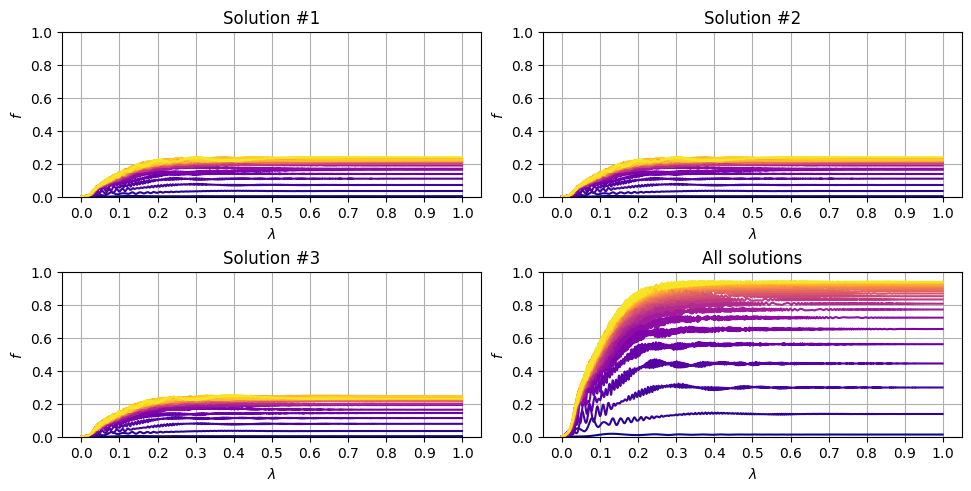

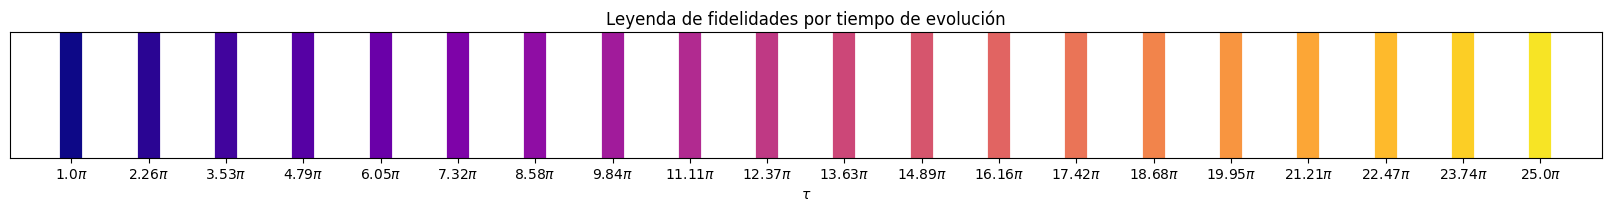

In [7]:
fidelities_5 = truncar_5_canales(fidelities)

suptitles = ['Solution #1', 'Solution #2', 'Solution #3', 'All solutions', 'All solutions']

plotFidelities(
    fidelities=fidelities_5,
    suptitles=suptitles[:4],
    res=res,
    runs=runs,
    tmax=25
)

plotLegend(
    suptitle="Leyenda de fidelidades por tiempo de evolución",
    res=res,
    runs=runs,
    tmax=25
)